# **🌳 '사회기반시설'과 '청년 수'와 관련된 데이터셋 입니다.**

도시를 새로 만들 때는 시민들을 위한 기반 시설을 설계하는 것이 중요하다.

기반 시설이 충분히 갖춰진 도시에 사람이 많이 모이기 때문이다.

도시 계획을 위해 **도서관 수와 공연장 수에 따른 청년 인구 수를 예측**해보자.

**✔️ [파일] - [Drive에 사본 저장]**

### **⭐ sklearn(사이킷런)?**
- 분류, 회귀, 군집화 등 다양한 기계학습 알고리즘을 지원하는데 각 알고리즘이 클래스로 제공

ex. LogisticRegression 클래스를 바로 호출해 로지스틱 알고리즘 학습과 예측을 손쉽게 실행 가능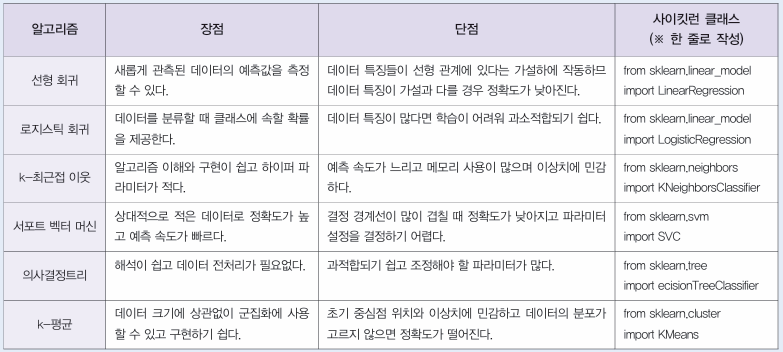

## 📍 데이터 가져오기

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [ ]:
from google.colab import files
files.upload()

Saving youth population.csv to youth population.csv


{'youth population.csv': b'\xec\xb2\xad\xeb\x85\x84,\xeb\x8f\x84\xec\x84\x9c\xea\xb4\x80,\xeb\xb0\x95\xeb\xac\xbc\xea\xb4\x80,\xeb\xaf\xb8\xec\x88\xa0\xea\xb4\x80,\xea\xb3\xb5\xec\x97\xb0\xec\x9e\xa5\n79395,10,13,4,9\n92444,4,8,3,5\n48291,4,17,3,4\n18433,3,0,1,1\n6217,3,2,0,1\n17854,3,2,1,1\n10463,3,4,0,1\n12702,4,2,0,2\n7327,3,1,0,1\n4755,2,21,2,1\n6409,5,4,0,2\n5104,2,5,1,2\n9945,4,0,0,1\n4394,2,2,0,2\n4552,1,5,1,2\n6071,2,6,2,1\n5274,2,5,3,2\n4224,1,1,1,1\n84037,5,0,0,2\n113679,6,0,0,0\n65362,7,2,2,9\n125706,9,5,0,0\n72431,5,0,2,1\n59273,2,1,0,1\n136139,8,2,2,5\n124800,5,0,1,3\n67770,4,3,0,1\n90446,6,0,0,1\n234452,14,6,0,6\n75892,6,1,0,2\n178809,11,0,0,4\n22787,2,2,0,1\n111793,8,4,1,1\n127721,7,1,4,4\n120282,8,9,1,4\n85777,5,1,1,2\n81023,6,0,0,1\n17543,3,4,2,2\n50928,3,1,0,1\n167085,12,7,4,2\n78071,6,2,1,1\n166634,12,2,1,5\n80644,6,0,0,2\n42529,3,2,1,0\n77588,5,1,0,2\n73467,8,7,2,3\n124724,8,6,4,1\n100658,7,1,0,2\n128147,17,13,7,6\n63705,5,3,2,1\n61497,6,4,1,3\n146003,7,4,2,3\n29508

In [ ]:
df = pd.read_csv('youth population.csv')

In [ ]:
df.head() #다섯 행 출력 → 데이터가 모두 '수치형'임을 확인함.(회귀)

,청년,도서관,박물관,미술관,공연장
0,79395,10,13,4,9
1,92444,4,8,3,5
2,48291,4,17,3,4
3,18433,3,0,1,1
4,6217,3,2,0,1


In [ ]:
df.isnull().sum() #결측치 확인

,0
청년,0
도서관,0
박물관,0
미술관,0
공연장,0


In [ ]:
x = df[['도서관','공연장']] #독립변수
y = df[['청년']] #종속변수
x.shape, y.shape #행 개수, 열 개수
# 요약: 250개의 관측치에서, 2개의 독립변수로 1개의 종속변수 설명
# 확인요소: x와 y의 '행'개수는 반드시 같아야함!!

((250, 2), (250, 1))

## 📍 데이터 쪼개기

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)
# 확인요소: random_state = 0은 무작위로 행 추출을 의미, 만약 값을 하나의 수로 고정하면? 실행할 때마다 같은 결과 출력

x_train.shape, y_test.shape
#요약: (행 수) 200개=train data / 50개 =test data

((200, 2), (50, 1))

## **📍 모델 학습**

In [ ]:
model = LinearRegression() #선형 회귀 모델 생성
# 확인요소: 선형 회귀? 데이터 셋을 잘 대표하는 '회귀선' 찾는 모델

In [ ]:
model.fit(x_train, y_train) #fit()? 훈련 데이터를 독립변수, 종속변수 순으로 넘김(=데이터 학습)

LinearRegression()

In [ ]:
# coef_ = 기울기 / intercept_ = 절편
model.coef_, model.intercept_
# 회귀식 ▶ 청년(y)=14242.04*도서관+32.37*공연장-9829.62

(array([[14242.04185528,    32.37292493]]), array([-9829.62739872]))

## **📍 모델 평가**

✔️ 평가 결과
- 성능이 충분하다면? 그대로 활용
- 성능이 떨어진다면? 데이터 전처리나 학습 단계로 돌아가 모델의 성능을 개선

# **✨ 평가 지표**
① **평균제곱오차(MSE)**: 각각의 테스트 케이스에 대해 실제 정답과 모델이 예측한 값의 차이를 제곱한 것들의 평균(→RMSE)

(=값이 클 수록 오차가 큰 모델임을 뜻함.)




② **결정계수(R2 score)**: 실제값과 모델이 예측한 값을 활용해 예측 모델이 얼마나 유의미한지 계산

(=1에 가까울수록 실제값과 가깝게 예측, 0에 가까울수록 데이터의 평균을 맞추는 정도로 예측함을 뜻함.)

In [ ]:
Predicted = model.predict(x_test)
Predicted[:5] #모델이 예측한 값 처음 다섯 개 출력

array([[ 61412.9548026 ],
       [ 89994.15728795],
       [ 32928.87109204],
       [ 47203.28587225],
       [104236.19914323]])

In [ ]:
y_test.head() #실젯값 처음 다섯 개 출력

,청년
225,45151
122,129072
92,90129
157,80391
154,116402


In [ ]:
mean_squared_error(y_test, Predicted) #mean_squared_error() = 모델의 평균제곱오차

913614726.4980049

In [ ]:
model.score(x_test, y_test) #score() = 결정계수

0.6401679820099786

결정계수 값이 0보다는 1에 가까우므로 예측 모델로써의 역할을 할 수 있다고 본다.

하지만 더 정확하게 예측하는 모델을 목표로 한다면, 사용하는 속성을 바꿔 보거나, 테스트 데이터를 다르게 나누어 다시 학습시킬 수도 있다.